<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction         4622 non-null   int64  
 1   quantity            4622 non-null   int64  
 2   Item                4622 non-null   str    
 3   choice_description  3376 non-null   str    
 4   item_price          4622 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 462.1 KB
None 

   Transaction  quantity                                   Item  item_price
0            1         1           Chips and Fresh Tomato Salsa        2.39
1            1         1                                   Izze        3.39
2            1         1                       Nantucket Nectar        3.39
3            1         1  Chips and Tomatillo-Green Chili Salsa        2.39
4            2         2                           Chicken Bowl       16.98
50
                              Item  

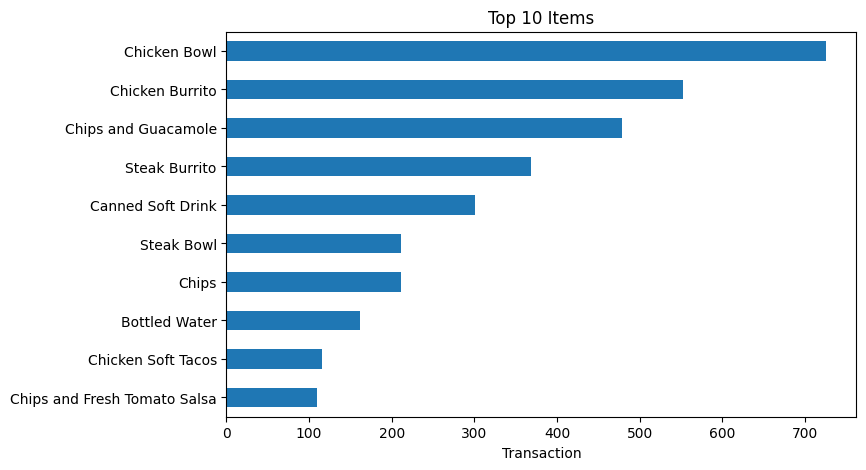

Transaction
1       [Chips and Fresh Tomato Salsa, Izze, Nantucket...
2                                          [Chicken Bowl]
3                           [Chicken Bowl, Side of Chips]
4                       [Steak Burrito, Steak Soft Tacos]
5                    [Steak Burrito, Chips and Guacamole]
                              ...                        
1830                      [Steak Burrito, Veggie Burrito]
1831                [Carnitas Bowl, Chips, Bottled Water]
1832            [Chicken Soft Tacos, Chips and Guacamole]
1833                                      [Steak Burrito]
1834                                 [Chicken Salad Bowl]
Name: Item, Length: 1834, dtype: object 

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]] 

   6 Pack Soft Drink  Barbacoa Bowl  Barba

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder

df = pd.read_csv('D:/2604340036 - 송성민/빅데이터/빅데이터/data/chipotle.csv')

print(df.info(), '\n')
print(df.iloc[:, [0, 1, 2, 4]].head())

print(len(df['Item'].unique()))
temp = df[df.item_price == df.item_price.max()]
temp = temp[['Item', 'item_price']].drop_duplicates()
print(temp, '\n')

temp = df[df.item_price == df.item_price.min()]
temp = temp[['Item', 'item_price']].drop_duplicates()
print(temp, '\n')

print(len(df['Transaction'].unique()))

sales_quantity = df.groupby('Item').count()
sales_quantity = sales_quantity.sort_values('Transaction', ascending = False)
print(sales_quantity['Transaction'], '\n')

top_ten = sales_quantity.sort_values('Transaction').tail(10)
top_ten = top_ten['Transaction']

top_ten.plot.barh(xlabel = 'Transaction',
                  ylabel = '',
                  title = 'Top 10 Items',
                  figsize = (9, 5))
plt.subplots_adjust(left = 0.2)
plt.show()

temp = df[['Transaction', 'Item']].drop_duplicates()
temp = temp.groupby('Transaction')['Item'].apply(list)
print(temp, '\n')

te = TransactionEncoder()
trans_matrix = te.fit(temp).transform(temp)
print(trans_matrix, '\n')

basket = pd.DataFrame(trans_matrix, columns = te.columns_)
print(basket.head(), '\n')

freq_item = apriori(df = basket, min_support = 0.01, use_colnames = True)
print(freq_item , '\n')

rules = association_rules(df = freq_item, metric = 'lift', min_threshold = 1,
                          num_itemsets = len(basket))
rules.sort_values('confidence', ascending = False, inplace = True)
print(rules.head(10), '\n')
print(rules.iloc[0, :].transpose())